<a href="https://colab.research.google.com/github/abner8888/TIMES/blob/main/%E2%80%9CPrice_Risk_Model_(Bhuwalka_et_al%3B_JIE)_ipynb%E2%80%9D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initialize

This block of code calls the necessary classes

In [ ]:
!pip install numpy_financial
!pip install shap
import shap
import numpy as np
import numpy_financial as npf
import pylab as p
import matplotlib.pyplot as plt
import pandas as pd
import seaborn
from scipy.optimize import curve_fit
import graphviz
from sklearn import tree

def func(x, a, b):
    return a*np.exp(-b*x)

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
np.random.seed(3)

# **Model** **Run**

The next block of code contains the model definition function; Input parameters have to be passed into the model

In [ ]:
 def run_model(cost_inc, tech_grow, sec_supply, sec_grow, sec_elasticity,capex_disc,capex_period,elasticity,mine_life,vol_grow,og_loss,resv,cac_slope,cap_prod_ratio,cc_steepness,ic_steepness,cap_intensity,current_margins,close_over_price,discovery,t):

  annualized_capex=npf.pmt(capex_disc,capex_period,-cap_intensity) #convert capital expenditure  to an annualized cost
  demand=1  #This variable represents primary consumption; in our analysis, we normalize demand and price (measure % changes)
  ovr_demand=1/(1-sec_supply)  #This variable represents primary+ secondary consumption
  time=1
  price=1
  lrprice=price #3 yr smoothing for price
  price0=price
  secondary=sec_supply  #This variable represents secondary consumption
  resv_used=0
  delprice=0

  #INITIALIZE INCENTIVE CURVE [Eqns from Section A.a.ii. in SI]
  incsize= cap_prod_ratio*demand
  q90inc,q25inc = [.9*incsize, .25*incsize] #defining 25th and 90th percentile quantities
  intercept_inc=price #At initalization incentive intercept is the price
  p25inc= (q90inc-q25inc)*price/(q90inc*ic_steepness-q25inc) #Use steepness to calculate cost of 25th percentile incentive mine
  p90inc= p25inc*ic_steepness #Use steepness to calculate cost of 90th percentile incentive mine
  slope_inc= (p90inc-p25inc)/(q90inc-q25inc)

  #INTITALIZE COST CURVES [Eqns from Section A.a.i. in SI]
  q90op,q25op=[.9,.25]  #as total quantity is 1, the 25th percentile quantity is 0.25
  p90op=price-current_margins #90th percentile cost is defined by price and margins
  p25op=p90op/cc_steepness #Use steepness to calculate cost of 25th percentile mine
  slope_op=(p90op-p25op)/(q90op-q25op) #Calculate Slope
  intercept_op=p90op-slope_op*q90op #Calculate Intercept
  most_exp= intercept_op+demand*slope_op #Calculate most expensive mine
  #initial_avg_cost= intercept_op+slope_op*.5

  for t1 in range(0,t):
    # t is the input parameter for total model run length

    #REDUCE SUPPLY DUE TO CLOSING, and the rest is shrunk because of og loss [Section SI A.b.iii]

    retire_econ=demand-min(demand,(lrprice*close_over_price-intercept_op)/slope_op) #mines close if 3yr average price is lower than cost; this line measures how many close
    remain= demand-retire_econ
    retire_og= og_loss*remain #loss in production due to OG reduction
    supply_loss=retire_econ+retire_og #total supply loss
    oldprod= demand-supply_loss
    most_exp= intercept_op+oldprod*slope_op

    #COST DEPLETION [Section SI A.b.vi.]
    p90op=(p90op/(1-og_loss))*(1-tech_grow)*(1+cost_inc) #change 90th percentile costs
    p25op=(p25op/(1-og_loss))*(1-tech_grow)*(1+cost_inc) #change 25th percentile costs
    intercept_op=(intercept_op/(1-og_loss))*(1-tech_grow)*(1+cost_inc) #recalculate intercept
    most_exp=(most_exp/(1-og_loss))*(1-tech_grow)*(1+cost_inc) #recalculate most expensive mine cost

    #DEMAND CHANGE [Section SI A.b.i]

    ovr_demand=max(0.00001,ovr_demand*(1+vol_grow)) #change in total demand from volume growth
    new_demand= demand*vol_grow +demand*(delprice*elasticity) #adjust demand based on price
    new_secondary= secondary*sec_grow + secondary*(delprice*sec_elasticity) #calculate increase in secondary supply
    demand= demand+ new_demand-new_secondary #calculate new primary demand
    secondary=secondary+new_secondary


    #PRICE FORMATION: INCENTIVE ADDED TO COST CURVE [Section SI A.b.v.]
    inc_cap_used= max(0.00001,new_demand+supply_loss-new_secondary) #how much incentive mine production must be opened
    delprice=(inc_cap_used*slope_inc+intercept_inc-price)/price # How much did price change
    price=inc_cap_used*slope_inc+intercept_inc #New price calculatted

    #NEW COST CURVES INITIALIZED [Section SI A.b.vi.]
    q90op=demand*.9 #new 90th percentile quantity
    q25op=demand*.25 #new 25th percentile quantity
    intercept_op=min((intercept_inc-annualized_capex),intercept_op) #New intercept is minimum of old intercept or cost of cheapest incentive mine that opened
    most_exp=max(most_exp,(price-annualized_capex)) #New most expensive mine is maximum of most expensive remaining mine or most expensive incentive mine that opened
    slope_op=(most_exp-intercept_op)/demand #recalculate slope
    p90op=intercept_op+slope_op*q90op #calculate 90th percentile
    p25op=intercept_op+slope_op*q25op #calculate 25th percentile cost
    cc_steepness=p90op/p25op

    #DEPLETE INCENTIVE QUANTITY
    #need to fill incentive
    amt_replenished= max(0.00001,cap_prod_ratio*demand - incsize + inc_cap_used) #how much is replenished in the incentive
    incsize=cap_prod_ratio*demand


    if incsize <= 0.00001:
      #Exit if there is nothing left in incentive
      return [price0, price/price0, demand, demand+secondary, incsize, resv_cost, secondary, p25op,p90op,intercept_inc,p90inc,resv_used,resv_left,inc_cap_used,t1]

    if .9*resv <= resv_used:
      #Exit if reserve used is >90% of the total reserve
      return [price0, price/price0, demand, demand+secondary, incsize, resv_cost, secondary, p25op,p90op,intercept_inc,p90inc,resv_used,resv_left,inc_cap_used,t1]

    if demand <= 0.1:
      #Exit if there is 10% of original demand left
      return [price0, price/price0, demand, demand+secondary, incsize, resv_cost, secondary, p25op,p90op,intercept_inc,p90inc,resv_used,resv_left,inc_cap_used,t1]

    q90inc = .9*incsize


    #DEPLETE RESERVE QUANTITY [Section SI A.b.vii.]

    resv=resv*(1+discovery) #reserve size increases due to discovery
    resv_used=resv_used + (amt_replenished)*mine_life #reserve is used up (moved to incentive)


    #FIND COST AT WHICH NEW RESERVE ENTERS INCENTIVE [Section SI A.b.vii.]
    resv_cost=0
    resv_cost = 1 + resv_used*cac_slope*((1+cost_inc-tech_grow)**t1) #reserve cost increases based on CAC slope

    #FIND NEW INCENTIVE COSTS [Section SI A.b.viii]

    intercept_inc_depleted=intercept_inc+slope_inc*inc_cap_used
    intercept_inc=min(resv_cost,intercept_inc_depleted) #new intercept is a min of old intercept and cheapest entering resource
    p90inc=max(p90inc,resv_cost)

    #ADD GOVERNANCE and TECHGROWTH TO INCENTIVE COSTS

    p90inc=(p90inc-annualized_capex)*(1-tech_grow)*(1+cost_inc)+annualized_capex #adjust 90th percentile costs based on tech growth
    intercept_inc=(intercept_inc-annualized_capex)*(1-tech_grow)*(1+cost_inc)+annualized_capex #adjust cheapest incentive mine costs based on tech growth

    #CALCULATE NEW INCENTIVE SLOPE
    slope_inc=(-intercept_inc+p90inc)/q90inc

    if(t<=1):
      price0=price

    lrprice=(2*lrprice+price)/3

    resv_left= resv-resv_used

  #SAVE VALUES
  return [price0, price/price0, demand, demand+secondary, incsize, resv_cost, secondary, p25op,p90op,intercept_inc,p90inc,resv_used,resv_left,inc_cap_used,t1]


# Full simulations


## Sample Parameters


Following block contains all input parameter ranges

In [ ]:
def sample_parameters():

  #See SI Section  B and C

  capex_disc=.15 #discount rate for CAPEX
  capex_period=10 #discount period for CAPEZ
  cap_intensity=np.random.uniform(1,3) #capital intensity
  elasticity= np.random.uniform(-0,-0.8)  #price elasticity of demand
  sec_supply=np.random.uniform(0.01,0.25) #percentage of supply from secondary sources at t=0
  sec_elasticity=np.random.uniform(0,0.5) #price elasticity of secondary supply
  mine_life=25 #average mine life
  vol_grow=np.random.uniform(0.00,0.06) #volume growth
  sec_grow=np.random.uniform(0,.05) #growth in secondary supply
  og_loss=np.random.uniform(0.01,0.03) #yearly ore grade loss for operating mines
  resv=np.random.uniform(150,650) #size of resources [#yrs of current production]
  cap_prod_ratio=np.random.uniform(.3,1) #ratio of incentive capacity and current prodcution
  cc_steepness=np.random.uniform(1.5,3) #steepness of cost curve
  ic_steepness=np.random.uniform(1.5,3) #steepness fo incentive curve
  current_margins=np.random.uniform(0.1,0.3) #margin of 90th percentile mine
  close_over_price=1 #how much does cost increase long term price for a mine to close (initialized as 1 so that ot closes as soon as cost exceeds LR price)
  discovery= 0 #rate of resource discovery (kept as 0)
  tech_grow=np.random.uniform(0,0.03) #cost decrease every year due to productivity gains
  cost_inc=np.random.uniform(0,0.03) #cost increase every year due to input prices
  t=30 #model run years
  cac_slope=np.random.uniform(0.005,0.025) #slope of cumulative availability curve


  return cost_inc, tech_grow, sec_supply, sec_grow, sec_elasticity,capex_disc,capex_period,elasticity,mine_life,vol_grow,og_loss,resv,cac_slope,cap_prod_ratio,cc_steepness,ic_steepness,cap_intensity,current_margins,close_over_price,discovery,t

## Run Simulations

In [ ]:
#Run 50,000 simualtions and store price change results
results=[]
for i in range (1,50000):
    cost_inc, tech_grow, sec_supply, sec_grow, sec_elasticity,capex_disc,capex_period,elasticity,mine_life,vol_grow,og_loss,resv,cac_slope,cap_prod_ratio,cc_steepness,ic_steepness,cap_intensity,current_margins,close_over_price,discovery,t = sample_parameters()
    resv0=resv
    [price0, pricechg, demand, ovr_demand, incsize, resv, secondary, p25op,p90op,intercept_inc,p90inc,resv_used,resv_left,inccapused,t_end]=run_model(cost_inc, tech_grow, sec_supply, sec_grow, sec_elasticity,capex_disc,capex_period,elasticity,mine_life,vol_grow,og_loss,resv,cac_slope,cap_prod_ratio,cc_steepness,ic_steepness,cap_intensity,current_margins,close_over_price,discovery,t)
    results.append([t_end,cost_inc,tech_grow, price0,pricechg,demand,ovr_demand,secondary,incsize,cac_slope,resv_left,resv0,elasticity,vol_grow,og_loss,cap_prod_ratio,cc_steepness,ic_steepness,cap_intensity,current_margins,close_over_price,discovery,sec_supply, sec_grow, sec_elasticity])



NameError: name 'np' is not defined

In [ ]:
#save results to a DF

result_df=pd.DataFrame(results)
result_df.columns=['T_end','Cost Inc','Tech Growth','Price_0','Price Change','Primary Demand','Tot_Demand','Secondary','Final Incentive Size','CAC Slope','Final Reserve Size','Initial Reserve','Elasticity','Growth','OG_loss','Initial Incentive Size','CC Steepness','IC Steepness','Cap Intensity','Margins','Close over price','Discovery','sec_supply', 'sec_grow', 'sec_elasticity']
result_df['Primary%']=result_df['Primary Demand']/result_df['Tot_Demand']
result_df=result_df.dropna()


In [ ]:
result_df.to_csv('simulations_30y_sep22.csv')

##Run Simulations and output results at Multiple Time Steps

In [ ]:
#Previous block only saved 30th year price. This simulation will save prices for all years (to make Fig 3-6)
results2=[]
for i in range (1,1000):
    cost_inc, tech_grow, sec_supply, sec_grow, sec_elasticity,capex_disc,capex_period,elasticity,mine_life,vol_grow,og_loss,resv,cac_slope,cap_prod_ratio,cc_steepness,ic_steepness,cap_intensity,current_margins,close_over_price,discovery,t = sample_parameters()
    for t2 in range(1,50):
      [price0, pricechg, demand, ovr_demand, incsize, resv3, secondary, p25op,p90op,intercept_inc,p90inc,resv_used,resv_left,inccapused,t_end]=run_model(cost_inc, tech_grow, sec_supply, sec_grow, sec_elasticity,capex_disc,capex_period,elasticity,mine_life,vol_grow,og_loss,resv,cac_slope,cap_prod_ratio,cc_steepness,ic_steepness,cap_intensity,current_margins,close_over_price,discovery,t2)
      results2.append([i,t_end,pricechg, tech_grow, cost_inc, sec_supply, sec_grow, vol_grow, elasticity,og_loss, cac_slope])




In [ ]:
result_df_2=pd.DataFrame(results2)
result_df_2.columns=['Index','T','Price', 'Tech Growth', 'Cost Inc', 'Sec Supply', 'Sec Grow', 'Growth', 'Elasticity','OG_loss', 'CAC Slope']
result_df_2=result_df_2.dropna()



In [ ]:
result_df_2.to_csv('simulations_trajectory_sep22.csv')

# Plot Fig. 3

*   List item
*   List item




A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


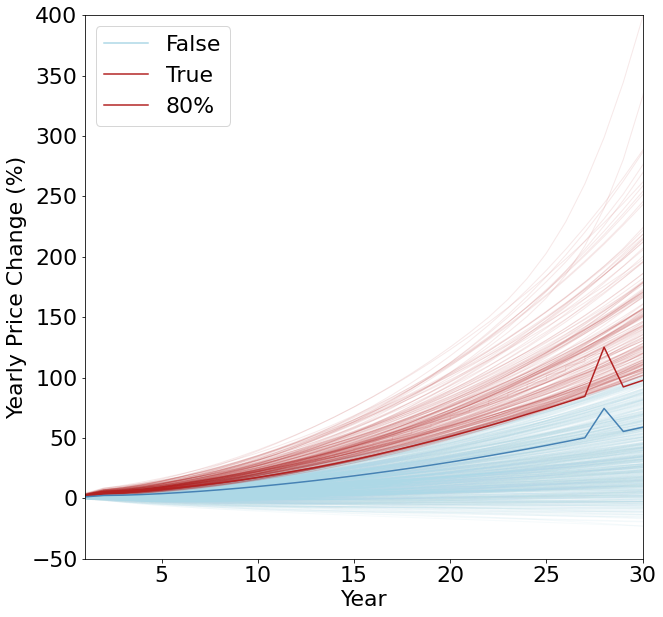

In [ ]:
result_df_2=result_df_2.dropna()
result_df_2['Net Productivity']=result_df_2['Tech Growth']-result_df_2['Cost Inc']
result_df_2['Demand Growth']=result_df_2['OG_loss']+result_df_2['Growth']


result_df_T=result_df_2[(result_df_2['T']==28)]
cutoff=result_df_T['Price'].quantile(.8)
result_df_T['Critical']=result_df_T['Price']>cutoff
result_df_T=result_df_T[['Index','T','Price','Critical']]
result_df_T.columns=['Index','T_30','Price_30','Critical']

result_df_3=pd.merge(result_df_2,result_df_T.reset_index())
result_df_3['Price']=(result_df_3['Price']-1)*100
result_df_3['Price']=result_df_3['Price'].rolling(2).mean()
import seaborn as sns

plt.figure(figsize=(10, 10))
plt.rcParams.update({'font.size': 22})

#result_df_3=result_df_3.loc[result_df_3['T']<=30]

sns.lineplot(x="T", y="Price", units="Index",data=result_df_3,lw=1,alpha=.1,hue="Critical", estimator=None, palette=['lightblue','firebrick'])
sns.lineplot(data=result_df_3.groupby(['T']).describe(percentiles=[.8])['Price'][['80%']], palette=['firebrick'], dashes=False)
sns.lineplot(data=result_df_3.groupby(['T']).mean()['Price'], color='steelblue', dashes=False)

plt.xlabel('Year')
plt.ylim(-50,400)
plt.xlim(1,30)
plt.ylabel('Yearly Price Change (%)')
plt.show()

In [ ]:
result_df_3.to_csv('fig3.csv')


# Plot Fig 4

<Figure size 720x720 with 0 Axes>

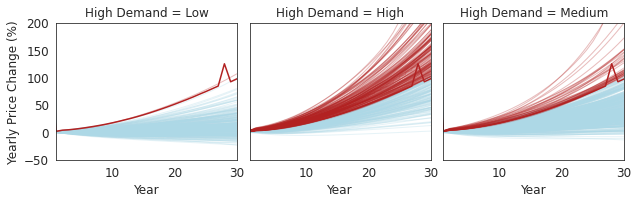

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 10))
plt.rcParams.update({'font.size': 12})


result_df_3['Increasing Productivity']='High'
result_df_3.loc[result_df_3['Net Productivity']<.01,'Increasing Productivity']='Medium'
result_df_3.loc[result_df_3['Net Productivity']<-.01,'Increasing Productivity']='Low'


result_df_3['High Demand']='High'
result_df_3.loc[result_df_3['Demand Growth']<.06333,'High Demand']='Medium'
result_df_3.loc[result_df_3['Demand Growth']<.03666,'High Demand']='Low'

result_df_3['Resource Quality']='Low'
result_df_3.loc[result_df_3['CAC Slope']<.019,'Resource Quality']='Medium'
result_df_3.loc[result_df_3['CAC Slope']<.012,'Resource Quality']='High'


#sns.set(font_scale = 1)
sns.set_style("white")
sns.set_palette(sns.color_palette(['lightblue','firebrick']))
g = sns.FacetGrid(result_df_3, col="High Demand", margin_titles=True, despine=False)
g.map_dataframe(sns.lineplot, x="T", y="Price", units="Index", hue="Critical",lw=1,alpha=.3,estimator=None)
#g.map_dataframe(sns.lineplot, x="T", y="Price", units="Index",lw=1,alpha=.2,hue="High Elasticity",estimator=None,palette='Set1',ci='sd')


axes = g.fig.axes
for ax in axes:
    ax.plot(result_df_3.groupby(['T']).describe(percentiles=[.8])['Price'][['80%']],color='firebrick')
g.set_axis_labels("Year", "Yearly Price Change (%)")

g.set(ylim=(-50,200))
g.set(xlim=(1,30))

plt.show()

In [ ]:
result_df_3.to_csv('fig4.csv')

# Plot Fig 5

<Figure size 720x720 with 0 Axes>

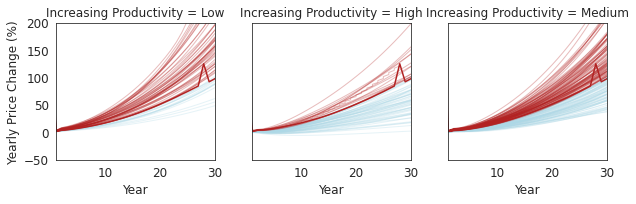

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 10))
plt.rcParams.update({'font.size': 12})


result_df_3['Increasing Productivity']='High'
result_df_3.loc[result_df_3['Net Productivity']<.01,'Increasing Productivity']='Medium'
result_df_3.loc[result_df_3['Net Productivity']<-.01,'Increasing Productivity']='Low'


result_df_3['High Demand']='High'
result_df_3.loc[result_df_3['Demand Growth']<.06333,'High Demand']='Medium'
result_df_3.loc[result_df_3['Demand Growth']<.03666,'High Demand']='Low'

result_df_3['Resource Quality']='Low'
result_df_3.loc[result_df_3['CAC Slope']<.019,'Resource Quality']='Medium'
result_df_3.loc[result_df_3['CAC Slope']<.012,'Resource Quality']='High'

#sns.set(font_scale = 1)
sns.set_style("white")
sns.set_palette(sns.color_palette(['lightblue','firebrick']))
g = sns.FacetGrid(result_df_3.loc[result_df_3['High Demand']=='High'], col="Increasing Productivity",margin_titles=True, despine=False)
g.map_dataframe(sns.lineplot, x="T", y="Price", units="Index", hue="Critical",lw=1,alpha=.3,estimator=None)
#g.map_dataframe(sns.lineplot, x="T", y="Price", units="Index",lw=1,alpha=.2,hue="High Elasticity",estimator=None,palette='Set1',ci='sd')


axes = g.fig.axes
for ax in axes:
    ax.plot(result_df_3.groupby(['T']).describe(percentiles=[.8])['Price'][['80%']],color='firebrick')
g.set_axis_labels("Year", "Yearly Price Change (%)")

g.set(ylim=(-50,200))
g.set(xlim=(1,30))

plt.show()

In [ ]:
result_df_3.to_csv('fig5.csv')

# Plot Fig 6

<Figure size 720x720 with 0 Axes>

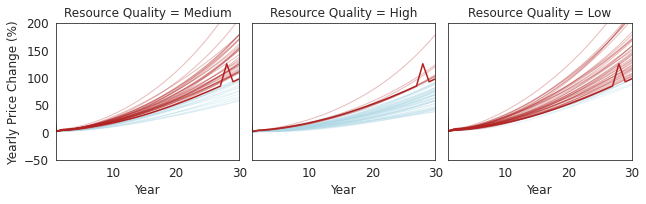

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 10))
plt.rcParams.update({'font.size': 12})


result_df_3['Increasing Productivity']='High'
result_df_3.loc[result_df_3['Net Productivity']<.01,'Increasing Productivity']='Medium'
result_df_3.loc[result_df_3['Net Productivity']<-.01,'Increasing Productivity']='Low'


result_df_3['High Demand']='High'
result_df_3.loc[result_df_3['Demand Growth']<.06333,'High Demand']='Medium'
result_df_3.loc[result_df_3['Demand Growth']<.03666,'High Demand']='Low'

result_df_3['Resource Quality']='Low'
result_df_3.loc[result_df_3['CAC Slope']<.019,'Resource Quality']='Medium'
result_df_3.loc[result_df_3['CAC Slope']<.012,'Resource Quality']='High'

#sns.set(font_scale = 1)
sns.set_style("white")
sns.set_palette(sns.color_palette(['lightblue','firebrick']))
g = sns.FacetGrid(result_df_3.loc[(result_df_3['High Demand']=='High')&(result_df_3['Increasing Productivity']=='Medium') ], col="Resource Quality",margin_titles=True, despine=False)
g.map_dataframe(sns.lineplot, x="T", y="Price", units="Index", hue="Critical",lw=1,alpha=.3,estimator=None)
#g.map_dataframe(sns.lineplot, x="T", y="Price", units="Index",lw=1,alpha=.2,hue="High Elasticity",estimator=None,palette='Set1',ci='sd')


axes = g.fig.axes
for ax in axes:
    ax.plot(result_df_3.groupby(['T']).describe(percentiles=[.8])['Price'][['80%']],color='firebrick')
g.set_axis_labels("Year", "Yearly Price Change (%)")

g.set(ylim=(-50,200))
g.set(xlim=(1,30))

plt.show()

In [ ]:
result_df_3.to_csv('fig6.csv')

#Decision tree (fig 7)

##Create Data Input

In [ ]:

def classify(results):


  result_df_redo=pd.DataFrame(results)
  result_df_redo.columns=['T_end','Cost Inc','Tech Growth','Price_0','Price Change','Primary Demand','Tot_Demand','Secondary','Final Incentive Size','CAC Slope','Final Reserve Size','Initial Reserve','Elasticity','Growth','OG_loss','Initial Incentive Size','CC Steepness','IC Steepness','Cap Intensity','Margins','Close over price','Discovery','sec_supply', 'sec_grow', 'sec_elasticity']
  result_df_redo=result_df_redo.dropna()


  cutoff=result_df_redo['Price Change'].quantile(.8)

  #change parameters as mentioned in SI TableS4
  result_df_redo['Critical']=result_df_redo['Price Change']>cutoff
  result_df_redo['Net Productivity']=result_df_redo['Tech Growth']-result_df_redo['Cost Inc']
  result_df_redo['Demand Growth']=result_df_redo['Growth']+result_df_redo['OG_loss']
  result_df_redo['Recycling']=result_df_redo['sec_supply']*((1+result_df_redo['sec_grow'])**30)
  result_df_redo['Elasticity']= -result_df_redo['Elasticity']

  X=result_df_redo[['Demand Growth','Net Productivity','Recycling','CAC Slope','Elasticity','Margins','Cap Intensity','sec_elasticity','CC Steepness','IC Steepness','Initial Incentive Size']]
  y=result_df_redo['Critical']

  Xnew=X
  for VarX in Xnew.columns:
    s=pd.cut(Xnew[VarX],3, labels=['Low','Medium','High'])
    Xnew[VarX]=s

  return Xnew,y

input,output= classify(results)

tree_data=input.copy()
tree_data['Class']=output #class is a measure of if a simulation had price risk
tree_data


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,Demand Growth,Net Productivity,Recycling,CAC Slope,Elasticity,Margins,Cap Intensity,sec_elasticity,CC Steepness,IC Steepness,Initial Incentive Size,Class
0,High,High,Low,High,High,Medium,Medium,Medium,Medium,Low,Low,False
1,Medium,Medium,Low,High,Low,Low,Medium,Low,Medium,High,Low,True
2,Medium,Medium,Low,Medium,High,Medium,High,High,Low,Medium,Medium,False
3,Medium,Medium,Low,High,Medium,High,High,Low,Medium,Medium,Low,False
4,Low,Medium,Low,Medium,High,Medium,Medium,Medium,Low,High,High,False
...,...,...,...,...,...,...,...,...,...,...,...,...
49994,High,High,Medium,High,Medium,Medium,High,Medium,High,Low,Low,False
49995,Medium,Medium,Low,Medium,High,Medium,High,Low,High,Low,Low,False
49996,Low,High,Medium,Low,High,Medium,High,Medium,High,Medium,Low,False
49997,High,Low,Low,High,High,High,Medium,Medium,High,Low,Low,True


In [ ]:
tree_data.to_csv('fig7-cuts.csv')

##Run Tree

In [ ]:
one_hot_data = pd.get_dummies(input,drop_first=True) #Python doesnt take in categorical data so need to convert this to one_hot encoding
rf = tree.DecisionTreeClassifier(min_samples_leaf=10, max_depth=7)
rf.fit(one_hot_data,output);

feature_list = list(one_hot_data.columns)

## Plot Tree

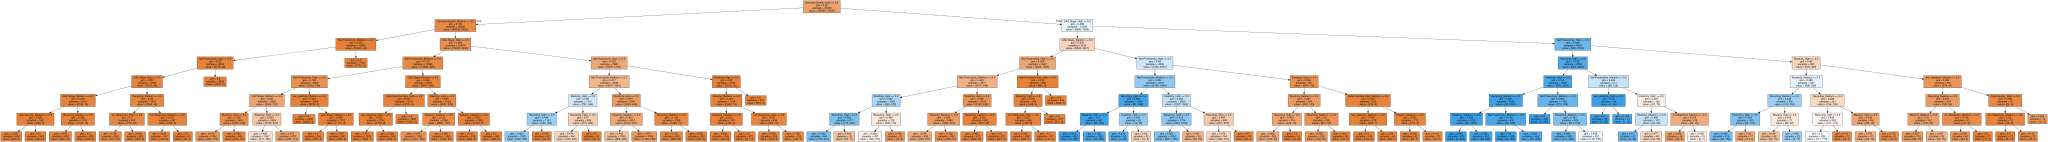

In [ ]:
dot_data = tree.export_graphviz(rf, out_file=None,
                                feature_names=feature_list,
                                filled=True)
# Draw graph
graph = graphviz.Source(dot_data, format="png")
graph